In [1]:
import numpy as np
import qiskit
from qiskit.visualization import circuit_drawer
from qiskit.quantum_info import Statevector
from matplotlib.pyplot import figure
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, Aer, assemble
from qiskit.providers.aer.noise import NoiseModel
import pylatexenc
from qiskit.algorithms import VQE
from qiskit.utils import QuantumInstance
from qiskit.opflow import X, Z, I, Y
from qiskit.circuit import Parameter
from qiskit.algorithms.optimizers import ADAM
from qiskit.opflow import AerPauliExpectation
from qiskit import IBMQ
import cmath
import pandas as pd
from scipy.sparse import diags
import numpy.linalg as LA
import matplotlib.pyplot as plt
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')
pi=np.pi

/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_11997/3965435209.py:7: DeprecationWarning: Importing from 'qiskit.providers.aer' is deprecated. Import from 'qiskit_aer' instead, which should work identically.
  from qiskit.providers.aer.noise import NoiseModel
/var/folders/td/3yk470mj5p931p9dtkk0y6jw0000gn/T/ipykernel_11997/3965435209.py:9: DeprecationWarning: ``qiskit.algorithms`` has been migrated to an independent package: https://github.com/qiskit-community/qiskit-algorithms. The ``qiskit.algorithms`` import path is deprecated as of qiskit-terra 0.25.0 and will be removed in Qiskit 1.0. Please run ``pip install qiskit_algorithms`` and use ``import qiskit_algorithms`` instead.
  from qiskit.algorithms import VQE


# <center> Lipkin Model </center>
\center
The Lipkin Model (LM) was introduced by H. Lipkin, N. Meshkov, and A. Glick in 1965. The model considers two levels above and bellow the fermi level to which they are assigned an index of $\sigma_{\pm}$ each with degeneracy $\Omega$ over which fermions are distributed. Using the language of second quantunization representation, the LM

\begin{equation}
    \hat{H}_{LM} = \frac{1}{2}\epsilon\sum_{m\sigma}a^{\dagger}_{m\sigma}a_{m\sigma} -\frac{1}{2}V\sum_{mm'\sigma}a^{\dagger}_{m\sigma}a^{\dagger}_{m'\sigma}a_{m'-\sigma}a_{m-\sigma} 
    \tag{1}
\end{equation}

where $\epsilon$ is the energy of the level, $V$ is the interaction strength, and $m=1,\cdots,\Omega$. The first term is a one-body interaction which counts the number of nucleons in the level. Where the second term is a two-body interaction that destroys and created nucleons up and down a level. One can introduce the quasi-spin operators defined as

\begin{equation}
    \begin{split}
        \hat{K}_0 &= \frac{1}{2}\sum_{m=1}^{\Omega}(a^{\dagger}_{m+}a_{m+}-a^{\dagger}_{m-}a_{m-})\\ 
        \hat{K}_+ & = \sum_{m=1}^{\Omega}a^{\dagger}_{m+}a_{m-}\\
        \hat{K}_- & = (\hat{K}_+)^\dagger
    \end{split}
    \tag{2}
\end{equation}

These operators have the following SU(2) angular momentum commutation relation
\begin{equation}
    [\hat{K}_+,\hat{K}_-] =2\hat{K}_0, \hspace{1cm} [\hat{K}_0,\hat{K}_{\pm}]=\pm\hat{K}_{\pm}
    \tag{3}
\end{equation}
The LM Hammiltonian can be written using the quasi-spin operators as such
\begin{equation}
    \hat{H}_{LM} = \epsilon\hat{K}_0 -\frac{1}{2}V(\hat{K}_+\hat{K}_++\hat{K}_-\hat{K}_-)
    \tag{4}
\end{equation}
The quasi-spin operators act like lowering and raising angular momentum operators, as such they have these given properties
\begin{equation}
        \hat{K}_0|KK_0\rangle = K_0|KK_0\rangle\\
        \tag{5}
\end{equation}
\begin{equation}
    \hat{K}_{\pm}|KK_0\rangle =\sqrt{K(K+1)-K_0(K_0\pm 1)}|KK_0+1\rangle
    \tag{6}
\end{equation}
With these properties we can calculate the LM Hamiltonian matrix
\begin{equation}
    \langle KK_0|H_{LM}|KK_0'\rangle
    \tag{7}
\end{equation}
Where the non-zero elements are given by
\begin{equation}
\begin{split}
    \langle KK_0|H_{LM}|KK_0'\rangle & = \epsilon K_0\\
    \langle KK_0|H_{LM}|KK_0'\pm 2\rangle & = \langle KK_0\pm 2|H_{LM}|KK_0'\rangle \\
    &= -\frac{1}{2}VC
\end{split}
    \tag{8}
\end{equation}
Where C is the Clebsch-Gordan Coefficients one gets when $K_{\pm}^2$ operates on the state $|KK_0\rangle$.
Using equation (8) one can calculate the exact solution to the Lipkin Model for any $\Omega$.

The collective space of the Hamiltonian is $\Omega+1=3$, and is given by
\begin{equation}
\begin{pmatrix}
-\epsilon & 0 & -V\\
0&0&0\\
-V&0&\epsilon
\end{pmatrix}
\end{equation}

In [2]:
#function that sorts eigenvalues with its eigenvectors in accending order
def eigen(A):
    eigenValues, eigenVectors = LA.eig(A)
    idx = np.argsort(eigenValues)
    eigenValues = eigenValues[idx]
    eigenVectors = eigenVectors[:,idx]
    return (eigenValues, eigenVectors) 

#one body expectation value
def one_body(E,N):
  k = N/2
  m = np.arange(-k,k+1,1) # Since the collective space is Omega+1
  return E*np.diag(m) #return a matrix where its diagonal elemens are epsilon*K_0

#two body expectation value
def two_body(V,N):
  k = N/2
  m = np.arange(-k,k+1,1)
  left =np.zeros(len(m)-2,dtype=complex)
  right = np.zeros(len(m)-2,dtype=complex)
  diag = np.zeros(len(m),dtype=complex)
  for i in range(len(left)):
    CG = cmath.sqrt(k*(k+1)-(m[i]+2)*(m[i]+1))*cmath.sqrt(k*(k+1)-m[i]*(m[i]+1)) #calculate Clebsch-Gordan Coefficients 
    left[i] = CG
    right[i] = CG
  k = [left,diag,right]
  offset = [-2,0,2]
  return -0.5*V*diags(k,offset).toarray() #return a matrix where its off digonal elements are (1/2)V(K^2_+ + K^2_-)

#full expectation value
def quasi_spin(E,V,N):
  ob = one_body(E,N)
  tb = two_body(V,N)
  H = ob+tb 
  e,v = eigen(H) # find the eigenvalues of the Hamiltonian
  return e,H

#converts chi to V
def Vp(E,omega,chi):
  return (chi*E)/(omega-1)

In [3]:
#parameters
E = 1
chi = np.arange(0,2.1,0.1)
omega = 2

EV0 = []
EV1 = []
EV2 = []
Ham = []
for i in chi:
  v = Vp(E,omega,i)
  EigenV,H = quasi_spin(E,v,omega) #return eigenvalues and Hamiltonian
  Ham.append(H)
  EV0.append(EigenV[0])
  EV1.append(EigenV[1])
  EV2.append(EigenV[2])

In [4]:
matrix = pd.DataFrame(Ham[5].real)
print('Hamiltonian matrix')
matrix.head()

Hamiltonian matrix


,0,1,2
0,-1.0,0.0,-0.5
1,0.0,0.0,0.0
2,-0.5,0.0,1.0


Text(0.5, 1.0, '$\\Omega=2$ exact Lipkin Model')

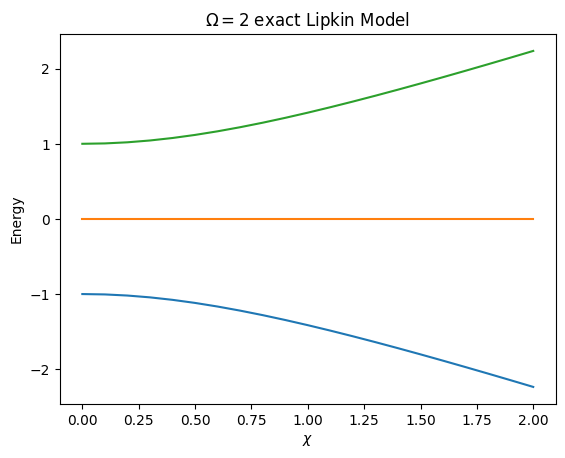

In [5]:
plt.plot(chi,EV0)
plt.plot(chi,EV1)
plt.plot(chi,EV2)
plt.xlabel('$\chi$')
plt.ylabel('Energy')
plt.title('$\Omega=2$ exact Lipkin Model')

# <center> Hartree Fock  </center>
A variational method in quantum mechanics, starts with the Schrodinger equation where one minimizes the energy for a given trail wave function $|\psi\rangle$.
\begin{equation}
    \delta\frac{\langle\psi |\hat{H}|\psi\rangle}{\langle\psi|\psi\rangle}=0
    \tag{9}
\end{equation}
The Hartree Fock (HF) method is a variational method that assumes that the exact N-body wavefunction of the system can be approimated by a single Slater determinant, where energy of the system is minimized and the trial wave function is the particle number conserving coherent product state. The SU(2) coherent states map a two-dimensional sphere known as the bloch sphere onto the complex plane,
\begin{equation}
    \tau = tan\frac{\theta}{2}e^{-i\phi}
    \tag{10}
\end{equation}
 where the normalized coherent SU(2) state can be written in the language of LM:
\begin{equation}
    |\tau\rangle = \frac{1}{(1+|\tau|^2)^{\Omega/2}}e^{\tau\hat{K}_+}|\frac{\Omega}{2},-\frac{\Omega}{2}\rangle
    \tag{11}
\end{equation}
The $E_{g.s}$ of the LM given HF coherent states is:
\begin{equation}
    E(\tau) = \langle \tau|\hat{H}_{LM}|\tau\rangle
    \tag{12}
\end{equation}
To calculate equation (12), we use generating functions for:
\begin{equation}
\begin{split}
\langle \tau|\hat{K}_{0}|\tau\rangle &= \frac{1}{2}\Omega\frac{|\tau|^2-1}{\tau|^2+1}\\
\langle \tau|\hat{K}_{\pm}^2|\tau\rangle &= \Omega\frac{\tau^*}{|\tau|^2+1}
\end{split}
\end{equation}
Then using the definition of $\tau$ in equation (10) we can write down the energy:
\begin{equation}
    E(\tau) = -\frac{\epsilon}{2}\Omega(cos\theta+\frac{\chi}{2}sin^2\theta cos2\phi)
    \tag{13}
\end{equation}
where $\chi=\frac{V}{\epsilon}(\Omega-1)$. Minimizing $E(\tau)$ with respect to $\theta,\phi$, we obtain the ground state Hartree Fock energy
\begin{equation}
    \begin{split}
        E_{HF}  = -\frac{\Omega}{2}\epsilon &\hspace{1cm} \chi<1\\
        E_{HF}  = -\frac{\Omega}{4}\epsilon(\chi+\frac{1}{\chi}) &\hspace{1cm} \chi\ge1
    \end{split}
    \tag{14}
\end{equation}

In [6]:
def E_HF(x,E,omega):
  if x < 1:
    EHF = -(omega/2)*E
  elif x >= 1:
    EHF = -(omega/4)*E*(x+(1/x))
  return EHF

In [7]:
epsilon = 1
Omega = 2

HF = []
exact = []
for x in chi:
    HF.append(E_HF(x,epsilon,omega).real)
    v = Vp(epsilon,omega,x)
    e,h = quasi_spin(epsilon,v,omega)
    exact.append(e[0].real)

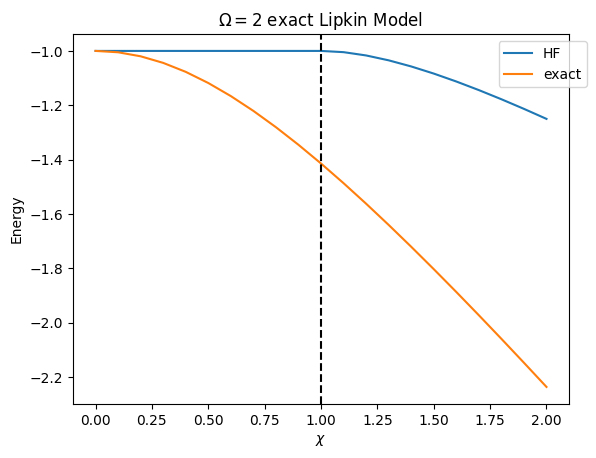

In [8]:
plt.plot(chi,HF,label='HF')
plt.plot(chi,exact,label='exact')
plt.xlabel('$\chi$')
plt.ylabel('Energy')
plt.axvline(1, color = 'k', linestyle='--')
plt.title('$\Omega=2$ exact Lipkin Model')
plt.legend(bbox_to_anchor=(1.05, 1))

# <center> Quantum Circuit  </center>
To solve the LM on a quantum computer we have to solve Schrodinger's equation. 
\begin{equation}
    H|\psi(\tilde{\theta})\rangle = E|\psi(\tilde{\theta})\rangle\\
\end{equation}
In \cite{LM2,LM1}, they take the LM Hamiltonian from equation (1) mapping the creation and annihilation operators to Pauli operators Z, X, Y using the Jordan-Wigner transformation. The Hamiltonian then takes the form of
\begin{equation}
      H = \frac{\epsilon}{2}(Z_1+Z_1) - \frac{V}{2}(X_1X_2 - Y_1Y_2)
\end{equation}
Where the Pauli operators are the measurement basis which the quantum circuit is measured in. However, before measuring, we first have to prepare the initial state $|\psi(\tilde{\theta})\rangle$ for $\Omega=2$ of the LM circuit
\begin{equation}
     |\psi(\tilde{\theta})\rangle = cos(\tilde{\theta})|00\rangle+sin(\tilde{\theta})|11\rangle
\end{equation}
Where $|00\rangle =|\uparrow\uparrow\rangle$, $|11\rangle=|\downarrow\downarrow\rangle$, and $\tilde{\theta}=\theta-\frac{\pi}{2}$. The LM circuit for $\Omega=2$ is:

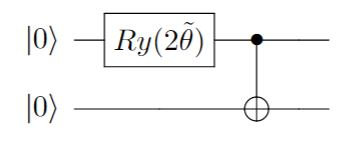

This type of problem resides in the pantheon of variational methods where we minimize $\tilde{\theta}$. This problem was coded using IBM's python library Qiskit. Since this is a variational problem, the use of Qiskit's Variational Quantum Eigensolver (VQE) was used to find the optimal $\tilde{\theta}$ that minimizes $\langle\psi(\tilde{\theta})|H|\psi(\tilde{\theta})\rangle$.

In [9]:
def LM_circuit():
    theta = Parameter('theta')
    QC = QuantumCircuit(2)
    QC.ry(2*(theta-np.pi/2),0)
    QC.cnot(0,1)
    return QC

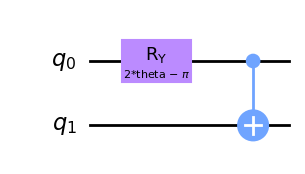

In [10]:
QC = LM_circuit()
QC.draw(output='mpl')

# <center> VQE method 1  </center>

For this method, we will be using Qiskit's VQE function, where we specifiy 

- Quantum circuit
-  Optimizer
-  Quantum instance (i.e. which backend). Here we will be using the "qasm_simulator" 
-  Initial point (i.e. $\theta$ search space)
- Hamiltonian/measurement basis

To define the Hamiltonian, we will use qiskit Pauli operator functions I,Z,X,Y

In this method, for a given $\chi$, we will do a search over $\theta$ from $-\frac{\pi}{2}$ to $\frac{\pi}{2}$ and picking out the minimum energy value

In [11]:
#sim1 min example
sim = Aer.get_backend('qasm_simulator')
adam =qiskit.algorithms.optimizers.ADAM(maxiter=10000) #optimizer for VQE
epsilon = 1
omega = 2
chi2 = [0.5,1]

t = np.arange(-pi/2,pi/2,0.05) #0.1 step size finishs pretty fast
energy = []
for x in chi2:
    ev = []
    v = Vp(epsilon,omega,x)
    for i in range(len(t)):
        H = 0.5 * epsilon * ( Z ^ I ) + \
            0.5 * epsilon * ( I ^ Z ) - \
            0.5 * v * ( X ^ X ) + \
            0.5 * v * ( Y ^ Y )

        vqe = VQE(ansatz=LM_circuit(),optimizer=adam,initial_point=[t[i]],quantum_instance=sim,expectation=AerPauliExpectation())
        result = vqe.compute_minimum_eigenvalue(H)
        ev.append(result.eigenvalue)
    energy.append(ev)

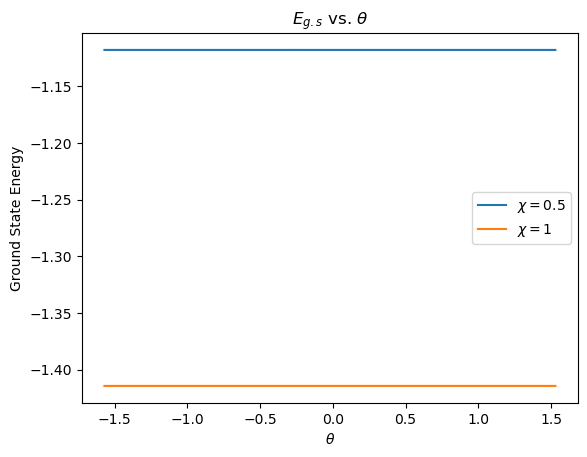

In [16]:
plt.plot(t,energy[0],label='$\chi=0.5$')
plt.plot(t,energy[1],label='$\chi=1$')

plt.xlabel('$\\theta$')
plt.ylabel('Ground State Energy')
plt.title('$E_{g.s}$ vs. $\\theta$')
plt.legend()

In [12]:
epsilon = 1
omega = 2
chi3 = np.arange(0,2.1,0.1)
t = np.arange(-pi/2,pi/2,0.1)
adam =qiskit.algorithms.optimizers.ADAM(maxiter=10000)
LM_sim = []
for x in chi3:
    v = Vp(epsilon,omega,x)
    ev = []
    for i in range(len(t)):
        H = 0.5 * epsilon * ( Z ^ I ) + \
           0.5 * epsilon * ( I ^ Z ) - \
           0.5 * v * ( X ^ X ) + \
           0.5 * v * ( Y ^ Y )
    
        vqe = VQE(ansatz=LM_circuit(),optimizer=adam,initial_point=[t[i]],quantum_instance=sim,expectation=AerPauliExpectation())
        result = vqe.compute_minimum_eigenvalue(H)

        ev.append(result.eigenvalue)
    LM_sim.append(min(ev))

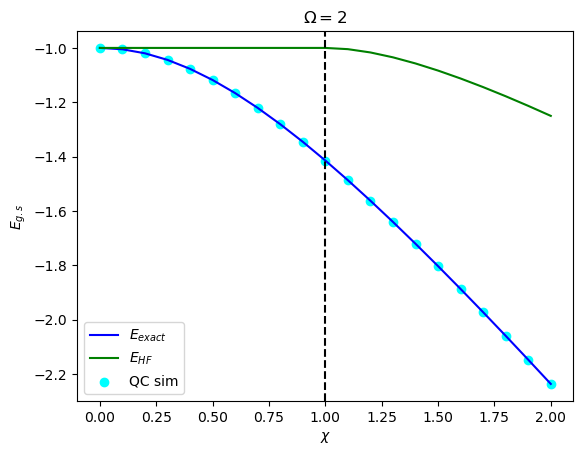

In [18]:
plt.plot(chi,np.array(exact),label='$E_{exact}$',color='b')
plt.plot(chi,np.array(HF),label='$E_{HF}$',color='g')
plt.scatter(chi3,LM_sim,label='QC sim',color='cyan')
plt.axvline(1, color = 'k', linestyle='--')
plt.ylabel('$E_{g.s}$')
plt.xlabel('$\chi$')
plt.title(f'$\Omega=2$')
plt.legend()

Here we will be running the same code, but with a noise model of IBM Quantum Computer Manila.

Note this code takes a lot longer to run, so maybe reduce range of $\chi$ and $t$ i.e. $\theta$.

In [13]:
IBMQ.load_account()
provider = IBMQ.get_provider()
IBMQC=provider.get_backend('ibmq_manila')
noise_model = NoiseModel.from_backend(IBMQC)
qi = QuantumInstance(backend=sim, noise_model=noise_model)

RequestsApiError: '401 Client Error: Unauthorized for url: https://auth.quantum-computing.ibm.com/api/users/loginWithToken. Login failed., Error code: 3446.'

In [ ]:
epsilon = 1
omega = 2
chi4 = np.arange(0,2.1,0.1)
t = np.arange(-pi/2,pi/2,0.1)
adam =qiskit.algorithms.optimizers.ADAM(maxiter=10000)
LM_sim_noise = []
for x in chi3:
    v = Vp(epsilon,omega,x)
    ev = []
    for i in range(len(t)):
        H = 0.5 * epsilon * ( Z ^ I ) + \
           0.5 * epsilon * ( I ^ Z ) - \
           0.5 * v * ( X ^ X ) + \
           0.5 * v * ( Y ^ Y )
    
        vqe = VQE(ansatz=LM_circuit(),optimizer=adam,initial_point=[t[i]],quantum_instance=qi,expectation=AerPauliExpectation())
        result = vqe.compute_minimum_eigenvalue(H)

        ev.append(result.eigenvalue)
    LM_sim_noise.append(min(ev))

In [ ]:
plt.plot(chi,np.array(exact),label='$E_{exact}$',color='b')
plt.plot(chi,np.array(HF),label='$E_{HF}$',color='g')
plt.scatter(chi3,LM_sim,label='QC sim',color='cyan')
plt.scatter(chi4,LM_sim_noise,label='QC sim with noise',color='r')
plt.axvline(1, color = 'k', linestyle='--')
plt.ylabel('$E_{g.s}$')
plt.xlabel('$\chi$')
plt.title(f'$\Omega=2$')
plt.legend()

# <center> VQE method 2  </center>

For this method, we will be using Qiskit's VQE function, where we specifiy 

- Quantum circuit
-  Optimizer
-  Quantum instance (i.e. which backend). Here we will be using the "statevector_simulator" 
- Hamiltonian/measurement basis

In [ ]:
epsilon = 1
omega = 2
chi5 = np.arange(0,2.1,0.1)
adam =qiskit.algorithms.optimizers.ADAM(maxiter=10000)
LM_sim = []
for x in chi5:
    v = Vp(epsilon,omega,x)
    
    H = 0.5 * epsilon * ( Z ^ I ) + \
       0.5 * epsilon * ( I ^ Z ) - \
       0.5 * v * ( X ^ X ) + \
       0.5 * v * ( Y ^ Y )
    
    vqe = VQE(ansatz=LM_circuit(),optimizer=adam,quantum_instance=vec,expectation=AerPauliExpectation())
    result = vqe.compute_minimum_eigenvalue(H)
    LM_sim.append(result.eigenvalue)

In [ ]:
plt.plot(chi,np.array(exact),label='$E_{exact}$',color='b')
plt.plot(chi,np.array(HF),label='$E_{HF}$',color='g')
plt.scatter(chi5,LM_sim,label='QC state vec',color='cyan')
plt.axvline(1, color = 'k', linestyle='--')
plt.ylabel('$E_{g.s}$')
plt.xlabel('$\chi$')
plt.title('$\Omega=2$')
plt.legend()

One thing to note is that method 2 only works for simulation. Where method 1 can work using IBM quantum computers. However, method 2 does run faster then method 1.